In [ ]:
!pip install transformers datasets torch seaborn matplotlib scikit-learn imbalanced-learn --quiet


In [ ]:
# ===========================
# 2) imports
# ===========================
import os
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import torch
from datasets import Dataset, DatasetDict
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    AutoModelForCausalLM,
    Trainer,
    TrainingArguments,
    DataCollatorWithPadding,
    pipeline
)

from imblearn.over_sampling import RandomOverSampler

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

OUT_DIR = "outputs"
os.makedirs(OUT_DIR, exist_ok=True)

In [ ]:
# ===========================
# 3) load datasets (robust)
# ===========================
def load_emp(path="empathetic_dialogues_train.csv"):
    df = pd.read_csv(path)
    # try to infer text column
    possible_text_cols = ["utterance", "text", "sentence", "dialogue", "context", "empathetic_dialogues"]
    text_col = None
    for c in possible_text_cols:
        if c in df.columns:
            text_col = c
            break
    if text_col is None:
        # fallback: take first object-like column
        obj_cols = [c for c in df.columns if df[c].dtype == 'object']
        if not obj_cols:
            raise ValueError("No suitable text column found in empathetic dataset.")
        text_col = obj_cols[0]

    # try to infer emotion column
    possible_emotion_cols = ["emotion", "label", "emotion_label"]
    emo_col = None
    for c in possible_emotion_cols:
        if c in df.columns:
            emo_col = c
            break
    if emo_col is None:
        raise ValueError("No emotion column found in empathetic dataset.")
    df = df[[text_col, emo_col]].rename(columns={text_col: "text", emo_col: "emotion"})
    df["emotion"] = df["emotion"].astype(str).str.strip().str.lower()
    df = df.dropna(subset=["text", "emotion"]).reset_index(drop=True)
    return df

def load_rocstories(path="rocstories_train.csv"):
    df = pd.read_csv(path)
    # ROCStories variants:
    # sometimes sentence1..sentence5; sometimes 'story' column
    if "story" in df.columns:
        df["story"] = df["story"].astype(str)
    else:
        sents = [c for c in df.columns if c.lower().startswith("sentence")]
        if not sents:
            # fallback: join all object columns
            obj_cols = [c for c in df.columns if df[c].dtype == 'object']
            if not obj_cols:
                raise ValueError("No suitable story columns found in ROCStories dataset.")
            df["story"] = df[obj_cols].astype(str).agg(" ".join, axis=1)
        else:
            sents = sorted(sents, key=lambda x: int("".join(filter(str.isdigit, x)) or 999))
            df["story"] = df[sents].astype(str).agg(" ".join, axis=1)
    df = df[["story"]].dropna().reset_index(drop=True)
    return df

emp_df = load_emp("empathetic_dialogues_train.csv")
roc_df = load_rocstories("rocstories_train.csv")

print("Empathetic rows:", len(emp_df))
print("ROCStories rows:", len(roc_df))
print("Empathetic head:\n", emp_df.head())
print("ROC head:\n", roc_df.head())

Empathetic rows: 64636
ROCStories rows: 78528
Empathetic head:
                                                 text      emotion
0  Customer :I remember going to see the firework...  sentimental
1  Customer :This was a best friend. I miss her.\...  sentimental
2              Customer :We no longer talk.\nAgent :  sentimental
3  Customer :Was this a friend you were in love w...  sentimental
4             Customer :Where has she gone?\nAgent :  sentimental
ROC head:
                                                story
0  The boy went to a video arcade. He played his ...
1  Jimmy was a big fan of cricket. In summer, his...
2  The baby shook from the cold room. His mother ...
3  Luke didn't want to pay 15 dollars for a movie...
4  Kara was very close to her mother when she was...


In [ ]:
# ===========================
# 4) map to super-sentiment (pos/neg/neutral)
# ===========================
pos_emotions = {
    'joyful','excited','grateful','hopeful','proud','content','trusting',
    'amused','impressed','confident','relieved','faithful','encouraged',
    'happy','delighted','optimistic','calm','satisfied','pleased','loving'
}
neg_emotions = {
    'sad','angry','afraid','anxious','devastated','furious','disgusted',
    'disappointed','guilty','ashamed','embarrassed','hurt','terrified',
    'jealous','lonely','disheartened','apprehensive','worried','bored',
    'frustrated','annoyed','depressed','upset','regretful','resentful'
}
def to_super(e):
    e = str(e).lower().strip()
    if e in pos_emotions: return "positive"
    if e in neg_emotions: return "negative"
    return "neutral"

emp_df["super"] = emp_df["emotion"].apply(to_super)

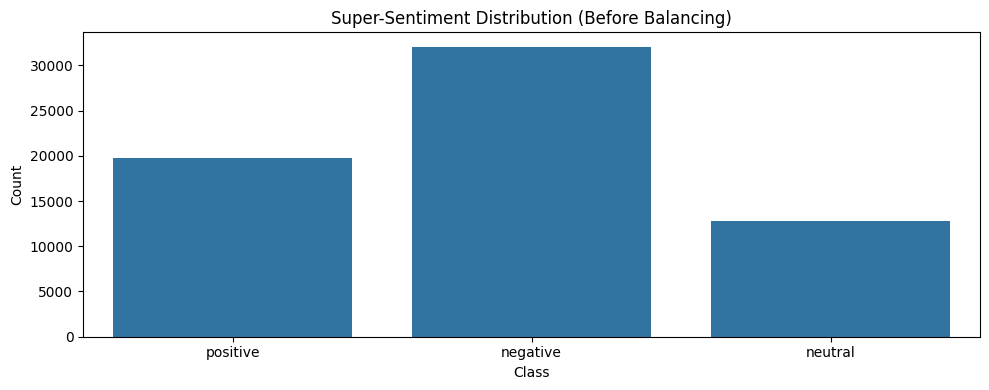

/tmp/ipython-input-3766963912.py:15: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(); plt.savefig(os.path.join(OUT_DIR, "emotion_dist_before.png")); plt.show()


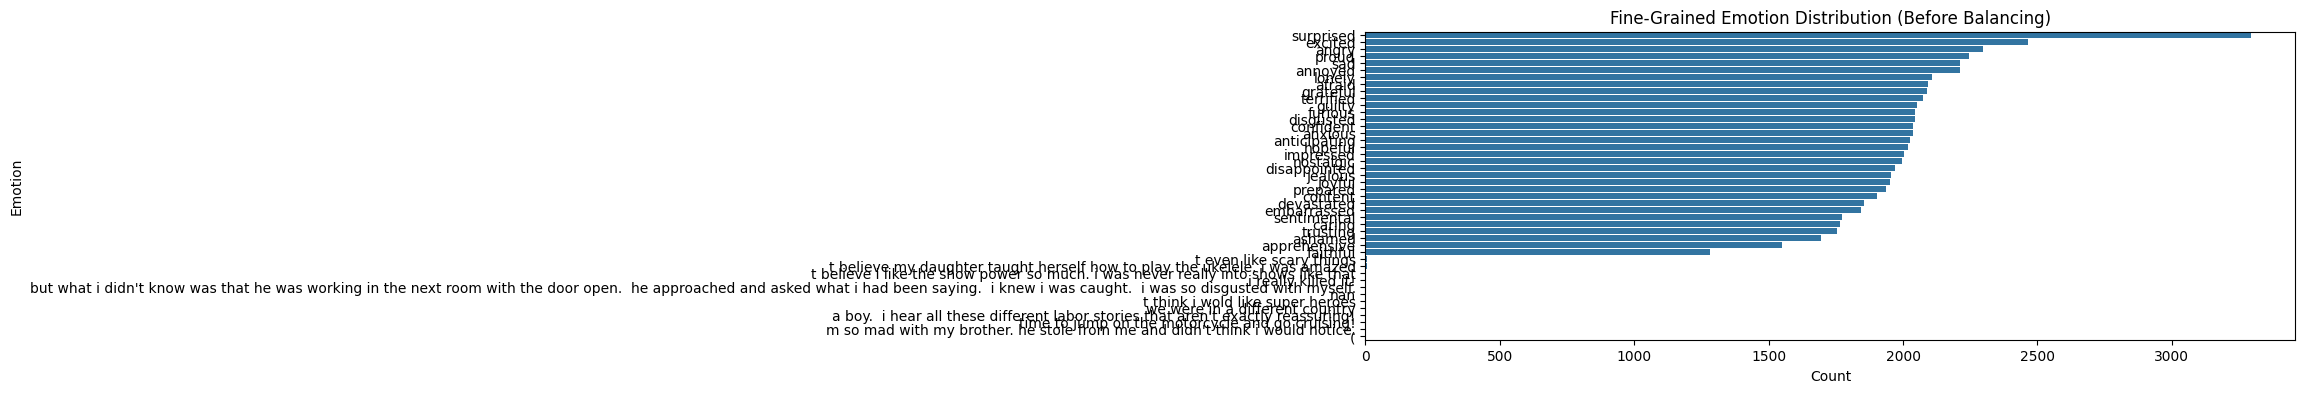

In [ ]:
# ===========================
# 5) visualize class distribution BEFORE balancing
# ===========================
plt.figure(figsize=(10,4))
sns.countplot(x="super", data=emp_df, order=["positive","negative","neutral"])
plt.title("Super-Sentiment Distribution (Before Balancing)")
plt.xlabel("Class"); plt.ylabel("Count")
plt.tight_layout(); plt.savefig(os.path.join(OUT_DIR, "super_dist_before.png")); plt.show()

plt.figure(figsize=(12,4))
order = emp_df["emotion"].value_counts().index
sns.countplot(y="emotion", data=emp_df, order=order)
plt.title("Fine-Grained Emotion Distribution (Before Balancing)")
plt.xlabel("Count"); plt.ylabel("Emotion")
plt.tight_layout(); plt.savefig(os.path.join(OUT_DIR, "emotion_dist_before.png")); plt.show()

In [ ]:
# ===========================
# 6) splits: train/val/test (stratify by super)
# ===========================
le_super = LabelEncoder()
emp_df["super_label"] = le_super.fit_transform(emp_df["super"])   # for stratify
# keep a separate encoder for fine-grained emotion
le_emo = LabelEncoder()
emp_df["emo_label"] = le_emo.fit_transform(emp_df["emotion"])

train_df, temp_df = train_test_split(
    emp_df, test_size=0.3, random_state=SEED, stratify=emp_df["super_label"]
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, random_state=SEED, stratify=temp_df["super_label"]
)
print("Splits:", len(train_df), len(val_df), len(test_df))

Splits: 45245 9695 9696


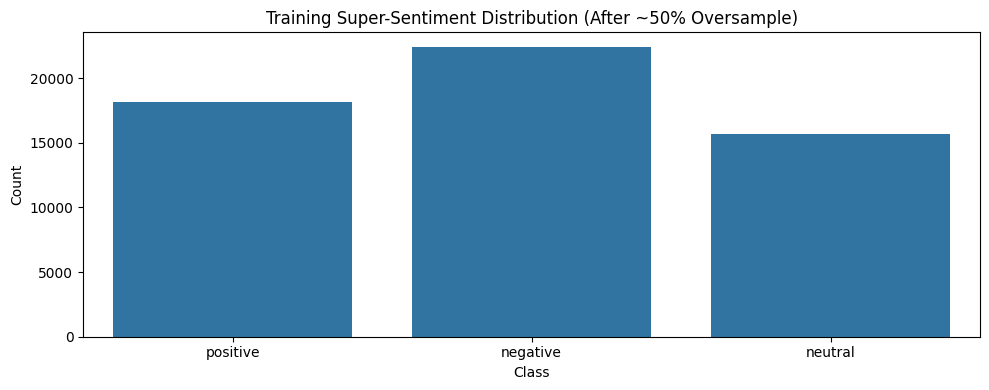

In [ ]:
# ===========================
# 7) balance ONLY TRAIN (toward ~50% of the gap to max)
# ===========================
def oversample_toward_majority(df, label_col, alpha=0.5):
    counts = Counter(df[label_col])
    max_count = max(counts.values())
    target_counts = {cls: int(count + alpha * (max_count - count)) for cls, count in counts.items()}
    ros = RandomOverSampler(sampling_strategy=target_counts, random_state=SEED)
    X_res, y_res = ros.fit_resample(df[["text"]], df[label_col])
    df_new = pd.DataFrame({"text": X_res["text"], label_col: y_res})
    return df_new

# for super sentiment
train_super_bal = oversample_toward_majority(
    train_df[["text","super_label"]].copy(), "super_label", alpha=0.5
)
# restore human-readable columns
train_super_bal["super"] = le_super.inverse_transform(train_super_bal["super_label"])

# plot after balancing
plt.figure(figsize=(10,4))
sns.countplot(x="super", data=train_super_bal, order=["positive","negative","neutral"])
plt.title("Training Super-Sentiment Distribution (After ~50% Oversample)")
plt.xlabel("Class"); plt.ylabel("Count")
plt.tight_layout(); plt.savefig(os.path.join(OUT_DIR, "super_dist_after.png")); plt.show()

In [ ]:
# ===========================
# 8) tokenization (roberta base)
# ===========================
clf_model_name = "roberta-base"
tokenizer = AutoTokenizer.from_pretrained(clf_model_name)

def tok_fn(batch):
    return tokenizer(batch["text"], padding="max_length", truncation=True, max_length=128)

# build datasets for super-sentiment (3-class)
sup_train_ds = Dataset.from_pandas(train_super_bal[["text","super_label"]].rename(columns={"super_label":"labels"}))
sup_val_ds   = Dataset.from_pandas(val_df[["text","super_label"]].rename(columns={"super_label":"labels"}))
sup_test_ds  = Dataset.from_pandas(test_df[["text","super_label"]].rename(columns={"super_label":"labels"}))
sup_train_ds = sup_train_ds.map(tok_fn, batched=True); sup_val_ds = sup_val_ds.map(tok_fn, batched=True); sup_test_ds = sup_test_ds.map(tok_fn, batched=True)
sup_train_ds = sup_train_ds.remove_columns([c for c in sup_train_ds.column_names if c not in ["input_ids","attention_mask","labels"]])
sup_val_ds   = sup_val_ds.remove_columns([c for c in sup_val_ds.column_names   if c not in ["input_ids","attention_mask","labels"]])
sup_test_ds  = sup_test_ds.remove_columns([c for c in sup_test_ds.column_names  if c not in ["input_ids","attention_mask","labels"]])
sup_train_ds.set_format("torch"); sup_val_ds.set_format("torch"); sup_test_ds.set_format("torch")

# datasets for fine-grained emotion (multi-class) — no balancing here
emo_train_ds = Dataset.from_pandas(train_df[["text","emo_label"]].rename(columns={"emo_label":"labels"}))
emo_val_ds   = Dataset.from_pandas(val_df[["text","emo_label"]].rename(columns={"emo_label":"labels"}))
emo_test_ds  = Dataset.from_pandas(test_df[["text","emo_label"]].rename(columns={"emo_label":"labels"}))
emo_train_ds = emo_train_ds.map(tok_fn, batched=True); emo_val_ds = emo_val_ds.map(tok_fn, batched=True); emo_test_ds = emo_test_ds.map(tok_fn, batched=True)
emo_train_ds = emo_train_ds.remove_columns([c for c in emo_train_ds.column_names if c not in ["input_ids","attention_mask","labels"]])
emo_val_ds   = emo_val_ds.remove_columns([c for c in emo_val_ds.column_names   if c not in ["input_ids","attention_mask","labels"]])
emo_test_ds  = emo_test_ds.remove_columns([c for c in emo_test_ds.column_names  if c not in ["input_ids","attention_mask","labels"]])
emo_train_ds.set_format("torch"); emo_val_ds.set_format("torch"); emo_test_ds.set_format("torch")


Map:   0%|          | 0/56265 [00:00<?, ? examples/s]

Map:   0%|          | 0/9695 [00:00<?, ? examples/s]

Map:   0%|          | 0/9696 [00:00<?, ? examples/s]

Map:   0%|          | 0/45245 [00:00<?, ? examples/s]

Map:   0%|          | 0/9695 [00:00<?, ? examples/s]

Map:   0%|          | 0/9696 [00:00<?, ? examples/s]

In [ ]:
# ===========================
# 9) define models + trainers
# ===========================
from sklearn.metrics import accuracy_score, f1_score, precision_recall_fscore_support

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, preds)
    f1w = f1_score(labels, preds, average="weighted")
    p, r, f1m, _ = precision_recall_fscore_support(labels, preds, average="macro", zero_division=0)
    return {"accuracy": acc, "f1_weighted": f1w, "f1_macro": f1m, "precision_macro": p, "recall_macro": r}

# --- super sentiment classifier
num_super = len(le_super.classes_)
sup_model = AutoModelForSequenceClassification.from_pretrained(clf_model_name, num_labels=num_super)

sup_args = TrainingArguments(
    output_dir="./emotion_super_model",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_steps=50,
    report_to="none",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True
)
sup_trainer = Trainer(
    model=sup_model,
    args=sup_args,
    train_dataset=sup_train_ds,
    eval_dataset=sup_val_ds,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
    data_collator=DataCollatorWithPadding(tokenizer)
)
sup_trainer.train()

# --- fine-grained emotion classifier
num_emo = len(le_emo.classes_)
emo_model = AutoModelForSequenceClassification.from_pretrained(clf_model_name, num_labels=num_emo)

emo_args = TrainingArguments(
    output_dir="./emotion_fine_model",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_steps=50,
    report_to="none",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True
)
emo_trainer = Trainer(
    model=emo_model,
    args=emo_args,
    train_dataset=emo_train_ds,
    eval_dataset=emo_val_ds,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
    data_collator=DataCollatorWithPadding(tokenizer)
)
emo_trainer.train()

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-31484523.py:33: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  sup_trainer = Trainer(


Epoch,Training Loss,Validation Loss,Accuracy,F1 Weighted,F1 Macro,Precision Macro,Recall Macro
1,0.714000,0.695421,0.712120,0.713989,0.672419,0.671202,0.674456
2,0.568400,0.710656,0.717071,0.718705,0.678532,0.678941,0.680234
3,0.430500,0.792921,0.715420,0.715981,0.673048,0.673079,0.673573


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-31484523.py:63: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  emo_trainer = Trainer(


Epoch,Training Loss,Validation Loss,Accuracy,F1 Weighted,F1 Macro,Precision Macro,Recall Macro
1,2.325500,2.289180,0.346261,0.332385,0.293168,0.312065,0.303581
2,2.077000,2.221921,0.364930,0.353435,0.313660,0.322123,0.321760
